In [1]:
!pip install -q transformers librosa wandb face-alignment dlib yacs pydub gfpgan kornia safetensors
!git clone https://github.com/OpenTalker/SadTalker.git 2>/dev/null || true

!mkdir -p SadTalker/checkpoints
!wget -q -nc "https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2/mapping_00109-model.pth.tar" -O SadTalker/checkpoints/mapping_00109-model.pth.tar
!wget -q -nc "https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2/mapping_00229-model.pth.tar" -O SadTalker/checkpoints/mapping_00229-model.pth.tar
!wget -q -nc "https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2-rc/SadTalker_V0.0.2_256.safetensors" -O SadTalker/checkpoints/SadTalker_V0.0.2_256.safetensors
!wget -q -nc "https://github.com/OpenTalker/SadTalker/releases/download/v0.0.2/BFM_Fitting.zip" -O /tmp/BFM_Fitting.zip
!unzip -qo /tmp/BFM_Fitting.zip -d SadTalker/checkpoints/

import safetensors
from pathlib import Path

ckpt = Path("SadTalker/checkpoints/SadTalker_V0.0.2_256.safetensors")
if ckpt.stat().st_size < 50_000_000:
    raise RuntimeError(f"Checkpoint seems too small ({ckpt.stat().st_size} bytes). Re-run this cell.")

try:
    with safetensors.safe_open(str(ckpt), framework="pt", device="cpu") as f:
        print(f"safetensor OK, tensors: {len(list(f.keys()))}")
except Exception as e:
    raise RuntimeError(f"Corrupted safetensor checkpoint: {e}")

!ls -lh SadTalker/checkpoints


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 19.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 25.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 60.4 MB/s eta 0:00:00
safetensor OK, tensors: 1305
total 989M
drwxr-xr-x 2 root root 4.0K Mar 14  2023 BFM_Fitting
drwxr-xr-x 3 root root 4.0K Mar 1

In [2]:
import sys
sys.path.insert(0, "/content")
sys.path.insert(0, "/content/SadTalker")
sys.path.insert(0, "/content/SadTalker/src")

import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from src.utils import audio as sadtalker_audio
from src.test_audio2coeff import Audio2Coeff
from src.utils.init_path import init_path

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
SADTALKER_CKPT = Path("/content/SadTalker/checkpoints")
OUT_DIR = Path("/content/sadtalker_finetuned")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MEL_CACHE_DIR = OUT_DIR / "_mel_cache"
COEFF_CACHE_DIR = OUT_DIR / "_coeff_cache"
MEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
COEFF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE = {0, 1, 3, 5, 7}
REMAP = {2: 0, 4: 1, 6: 2}
EMOTIONS = ["happy", "angry", "disgust"]

SR = 16000
FPS = 25
SYNCNET_MEL_STEP = 16

print(f"Device: {DEVICE}")


Device: cuda


In [3]:
def crop_pad_audio(wav, audio_length):
    if len(wav) > audio_length:
        wav = wav[:audio_length]
    elif len(wav) < audio_length:
        wav = np.pad(wav, [0, audio_length - len(wav)], mode="constant", constant_values=0)
    return wav


def parse_audio_length(audio_length, sr=SR, fps=FPS):
    bit_per_frame = sr / fps
    num_frames = int(audio_length / bit_per_frame)
    audio_length = int(num_frames * bit_per_frame)
    return audio_length, num_frames


def build_indiv_mels(audio_path):
    wav = sadtalker_audio.load_wav(audio_path, SR)
    wav_length, _ = parse_audio_length(len(wav), SR, FPS)
    wav = crop_pad_audio(wav, wav_length)

    orig_mel = sadtalker_audio.melspectrogram(wav).T
    spec = orig_mel.copy()
    indiv_mels = []

    num_frames = int(wav_length / (SR / FPS))
    for i in range(num_frames):
        start_frame_num = i - 2
        start_idx = int(80.0 * (start_frame_num / float(FPS)))
        end_idx = start_idx + SYNCNET_MEL_STEP
        seq = np.arange(start_idx, end_idx)
        seq = np.clip(seq, 0, orig_mel.shape[0] - 1)
        m = spec[seq, :]
        indiv_mels.append(m.T.astype(np.float32))

    return np.asarray(indiv_mels, dtype=np.float32)  # (T, 80, 16)


class SadTalkerAudioDataset(Dataset):
    def __init__(self, metadata_path, split):
        with open(metadata_path) as f:
            data = json.load(f)
        self.samples = [
            s for s in data
            if s["split"] == split and s["emotion_idx"] not in EXCLUDE
        ]
        if len(self.samples) == 0:
            raise ValueError(f"No samples for split={split}")

    def __len__(self):
        return len(self.samples)

    def mel_cache_path(self, sample_id):
        return MEL_CACHE_DIR / f"{sample_id}.npy"

    def coeff_cache_path(self, sample_id):
        return COEFF_CACHE_DIR / f"{sample_id}_exp64.npy"

    def __getitem__(self, idx):
        s = self.samples[idx]
        sample_id = s["sample_id"]
        mel_path = self.mel_cache_path(sample_id)
        coeff_path = self.coeff_cache_path(sample_id)

        if not mel_path.exists():
            raise FileNotFoundError(f"Missing mel cache for {sample_id}. Run cache cell first.")
        if not coeff_path.exists():
            raise FileNotFoundError(f"Missing coeff cache for {sample_id}. Run cache cell first.")

        indiv_mels = np.load(mel_path)
        gt_exp = np.load(coeff_path)

        return {
            "sample_id": sample_id,
            "audio_path": s["audio_path"],
            "indiv_mels": torch.from_numpy(indiv_mels),
            "gt_exp": torch.from_numpy(gt_exp),
            "emotion": REMAP[s["emotion_idx"]],
        }


def collate_sadtalker(batch):
    return {
        "sample_id": [b["sample_id"] for b in batch],
        "audio_path": [b["audio_path"] for b in batch],
        "indiv_mels": [b["indiv_mels"] for b in batch],
        "gt_exp": [b["gt_exp"] for b in batch],
        "emotion": torch.tensor([b["emotion"] for b in batch], dtype=torch.long),
    }


train_ds = SadTalkerAudioDataset(METADATA, "train")
val_ds = SadTalkerAudioDataset(METADATA, "val")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")


Train: 408, Val: 72


In [4]:
from src.face3d.models import networks
from src.utils.safetensor_helper import load_x_from_safetensor
import safetensors.torch


def load_face3drecon_model(ckpt_dir, device):
    ckpt_path = Path(ckpt_dir) / "SadTalker_V0.0.2_256.safetensors"
    net_recon = networks.define_net_recon(net_recon='resnet50', use_last_fc=False, init_path='').to(device)
    checkpoint = safetensors.torch.load_file(str(ckpt_path))
    net_recon.load_state_dict(load_x_from_safetensor(checkpoint, 'face_3drecon'))
    net_recon.eval()
    for p in net_recon.parameters():
        p.requires_grad = False
    return net_recon


@torch.no_grad()
def extract_gt_exp_coeff(frames_uint8, net_recon, device, batch_size=48):
    # frames_uint8: (T, H, W, 3), uint8
    x = torch.from_numpy(frames_uint8).permute(0, 3, 1, 2).float() / 255.0
    x = x.to(device)
    x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)

    out = []
    for i in range(0, x.shape[0], batch_size):
        coeff = net_recon(x[i:i+batch_size])   # (B, 257 or 256)
        exp = coeff[:, 80:144]                 # 64-d expression coeff
        out.append(exp.cpu())

    return torch.cat(out, dim=0).numpy().astype(np.float32)


def ensure_mel_cache(dataset, split_name):
    done = 0
    for s in tqdm(dataset.samples, desc=f"Mel cache [{split_name}]"):
        p = MEL_CACHE_DIR / f"{s['sample_id']}.npy"
        if p.exists():
            done += 1
            continue
        mel = build_indiv_mels(s["audio_path"])
        np.save(p, mel)
        done += 1
    print(f"{split_name}: mel cache ready for {done} samples")


def ensure_coeff_cache(dataset, split_name, net_recon):
    done = 0
    for s in tqdm(dataset.samples, desc=f"Coeff cache [{split_name}]"):
        p = COEFF_CACHE_DIR / f"{s['sample_id']}_exp64.npy"
        if p.exists():
            done += 1
            continue
        frames = np.load(s["frames_path"])  # (T, H, W, 3) uint8
        exp64 = extract_gt_exp_coeff(frames, net_recon, DEVICE)
        np.save(p, exp64)
        done += 1
    print(f"{split_name}: coeff cache ready for {done} samples")


net_recon = load_face3drecon_model(SADTALKER_CKPT, DEVICE)
ensure_mel_cache(train_ds, "train")
ensure_mel_cache(val_ds, "val")
ensure_coeff_cache(train_ds, "train", net_recon)
ensure_coeff_cache(val_ds, "val", net_recon)
del net_recon
torch.cuda.empty_cache()


def load_sadtalker_netg(ckpt_dir, device):
    sadtalker_paths = init_path(
        str(ckpt_dir),
        "/content/SadTalker/src/config",
        "256",
        False,
        "crop",
    )
    audio2coeff = Audio2Coeff(sadtalker_paths, device)
    netG = audio2coeff.audio2exp_model.netG.to(device)
    return netG


def set_trainable_layers(netG, mode="upper_audio"):
    for p in netG.parameters():
        p.requires_grad = False

    if mode == "mapping1":
        for p in netG.mapping1.parameters():
            p.requires_grad = True
    elif mode == "upper_audio":
        # Unfreeze mapping1 + last 4 conv blocks of audio encoder.
        for p in netG.mapping1.parameters():
            p.requires_grad = True
        for block in list(netG.audio_encoder.children())[-4:]:
            for p in block.parameters():
                p.requires_grad = True
    elif mode == "all":
        for p in netG.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"Unknown unfreeze mode: {mode}")


def count_params(module):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable


def make_ref_coeff_70(gt_exp):
    # gt_exp: (T, 64)
    ref = torch.zeros((1, 70), dtype=torch.float32, device=gt_exp.device)
    ref[0, :64] = gt_exp[0]
    return ref


def make_batch_dict(indiv_mels, ref_coeff_70, device):
    # indiv_mels: (T, 80, 16)
    T = indiv_mels.shape[0]
    ref = ref_coeff_70.repeat(T, 1).unsqueeze(0).to(device)  # (1, T, 70)
    ratio = torch.zeros((1, T), dtype=torch.float32, device=device)
    return {
        "indiv_mels": indiv_mels.unsqueeze(0).unsqueeze(2).to(device),  # (1, T, 1, 80, 16)
        "ref": ref,
        "ratio_gt": ratio,
    }


def predict_exp_coeff(netG, batch_dict):
    mel_input = batch_dict["indiv_mels"]
    ref = batch_dict["ref"][:, :, :64]
    ratio = batch_dict["ratio_gt"]

    preds = []
    for i in range(0, mel_input.shape[1], 10):
        cur_mel = mel_input[:, i:i+10]
        cur_ref = ref[:, i:i+10]
        cur_ratio = ratio[:, i:i+10]
        audiox = cur_mel.reshape(-1, 1, 80, 16)
        preds.append(netG(audiox, cur_ref, cur_ratio))

    return torch.cat(preds, dim=1)  # (1, T, 64)


net_preview = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
for mode in ["mapping1", "upper_audio", "all"]:
    set_trainable_layers(net_preview, mode)
    total, trainable = count_params(net_preview)
    print(f"mode={mode:11s} trainable={trainable/1e6:.3f}M / total={total/1e6:.3f}M")
del net_preview
torch.cuda.empty_cache()


Mel cache [train]: 100%|██████████| 408/408 [00:11<00:00, 36.33it/s] 


train: mel cache ready for 408 samples


Mel cache [val]: 100%|██████████| 72/72 [00:00<00:00, 148.54it/s]


val: mel cache ready for 72 samples


Coeff cache [train]: 100%|██████████| 408/408 [00:28<00:00, 14.22it/s]


train: coeff cache ready for 408 samples


Coeff cache [val]: 100%|██████████| 72/72 [00:02<00:00, 32.69it/s]


val: coeff cache ready for 72 samples
using safetensor as default
mode=mapping1    trainable=0.037M / total=2.850M
mode=upper_audio trainable=2.368M / total=2.850M
mode=all         trainable=2.850M / total=2.850M


In [5]:
wandb.login()

CONFIGS = [
    {"name": "sadtalker-baseline", "lambda_emo": 0.0},
    {"name": "sadtalker-emo-001",  "lambda_emo": 0.01},
    {"name": "sadtalker-emo-002",  "lambda_emo": 0.02},
    {"name": "sadtalker-emo-003",  "lambda_emo": 0.03},
    {"name": "sadtalker-emo-004",  "lambda_emo": 0.04},
    {"name": "sadtalker-emo-005",  "lambda_emo": 0.05},
    {"name": "sadtalker-emo-01",   "lambda_emo": 0.1},
]

UNFREEZE_MODE = "upper_audio"  # mapping1 | upper_audio | all
W_COEFF_EXP = 2.0               # original SadTalker coeff-exp weight

if UNFREEZE_MODE == "all":
    LR = 2e-5
    BATCH_SIZE = 4
elif UNFREEZE_MODE == "upper_audio":
    LR = 5e-5
    BATCH_SIZE = 6
else:
    LR = 1e-4
    BATCH_SIZE = 8

EPOCHS = 40
PATIENCE = 6
NUM_WORKERS = 0

print(f"Unfreeze mode: {UNFREEZE_MODE}, LR={LR}, BATCH_SIZE={BATCH_SIZE}, W_COEFF_EXP={W_COEFF_EXP}")


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: katrinpochtar to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Unfreeze mode: upper_audio, LR=5e-05, BATCH_SIZE=6, W_COEFF_EXP=2.0


In [6]:
# Original-like objective + your emotion loss:
#   L_total = W_COEFF_EXP * L_coeff_exp + lambda_emo * L_emo
# where L_coeff_exp is frame-wise L1 on 64-d expression coefficients.


def build_model_bundle(unfreeze_mode):
    netG = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
    set_trainable_layers(netG, unfreeze_mode)
    emo_head = nn.Linear(64, len(EMOTIONS)).to(DEVICE)

    total = sum(p.numel() for p in netG.parameters())
    trainable = sum(p.numel() for p in netG.parameters() if p.requires_grad)
    return netG, emo_head, total, trainable


def train_one_epoch(netG, emo_head, loader, optimizer, scaler, lambda_emo, w_coeff_exp):
    netG.train()
    emo_head.train()

    total_coeff, total_emo, total_loss = 0.0, 0.0, 0.0
    n_steps = 0

    for batch in tqdm(loader, leave=False):
        labels = batch["emotion"].to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        coeff_terms = []
        feats = []
        valid_labels = []

        with autocast("cuda", enabled=DEVICE == "cuda"):
            for i, indiv_mels in enumerate(batch["indiv_mels"]):
                try:
                    gt_exp = batch["gt_exp"][i].float().to(DEVICE)   # (Tg, 64)
                    if gt_exp.ndim != 2 or gt_exp.shape[1] != 64 or gt_exp.shape[0] < 2:
                        continue

                    ref_coeff_70 = make_ref_coeff_70(gt_exp)
                    bd = make_batch_dict(indiv_mels.float(), ref_coeff_70, DEVICE)
                    pred = predict_exp_coeff(netG, bd).squeeze(0)      # (Tp, 64)

                    T = min(pred.shape[0], gt_exp.shape[0])
                    if T < 2:
                        continue

                    pred_t = pred[:T]
                    gt_t = gt_exp[:T]

                    coeff_terms.append(F.l1_loss(pred_t, gt_t))
                    feats.append(pred_t.mean(dim=0))
                    valid_labels.append(labels[i])
                except Exception:
                    continue

            if not coeff_terms:
                continue

            coeff_exp = torch.stack(coeff_terms).mean()
            coeff_loss = w_coeff_exp * coeff_exp

            feats = torch.stack(feats, dim=0)
            valid_labels = torch.stack(valid_labels)

            cls_loss = F.cross_entropy(emo_head(feats.detach()), valid_labels)
            emo_loss = (
                F.cross_entropy(emo_head(feats), valid_labels)
                if lambda_emo > 0
                else torch.tensor(0.0, device=DEVICE)
            )

            report_loss = coeff_loss + lambda_emo * emo_loss
            loss = report_loss + cls_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_([p for p in netG.parameters() if p.requires_grad] + list(emo_head.parameters()), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_coeff += coeff_exp.item()
        total_emo += emo_loss.item()
        total_loss += report_loss.item()
        n_steps += 1

    if n_steps == 0:
        return {"recon": float("inf"), "emotion": float("inf"), "total": float("inf")}

    return {
        "recon": total_coeff / n_steps,
        "emotion": total_emo / n_steps,
        "total": total_loss / n_steps,
    }


@torch.no_grad()
def evaluate(netG, emo_head, loader, lambda_emo, w_coeff_exp):
    netG.eval()
    emo_head.eval()

    total_coeff, total_emo, total_loss = 0.0, 0.0, 0.0
    correct, total_samples = 0, 0
    n_steps = 0

    for batch in tqdm(loader, leave=False):
        labels = batch["emotion"].to(DEVICE)

        coeff_terms = []
        feats = []
        valid_labels = []

        with autocast("cuda", enabled=DEVICE == "cuda"):
            for i, indiv_mels in enumerate(batch["indiv_mels"]):
                try:
                    gt_exp = batch["gt_exp"][i].float().to(DEVICE)
                    if gt_exp.ndim != 2 or gt_exp.shape[1] != 64 or gt_exp.shape[0] < 2:
                        continue

                    ref_coeff_70 = make_ref_coeff_70(gt_exp)
                    bd = make_batch_dict(indiv_mels.float(), ref_coeff_70, DEVICE)
                    pred = predict_exp_coeff(netG, bd).squeeze(0)

                    T = min(pred.shape[0], gt_exp.shape[0])
                    if T < 2:
                        continue

                    pred_t = pred[:T]
                    gt_t = gt_exp[:T]

                    coeff_terms.append(F.l1_loss(pred_t, gt_t))
                    feats.append(pred_t.mean(dim=0))
                    valid_labels.append(labels[i])
                except Exception:
                    continue

            if not coeff_terms:
                continue

            coeff_exp = torch.stack(coeff_terms).mean()
            coeff_loss = w_coeff_exp * coeff_exp

            feats = torch.stack(feats, dim=0)
            valid_labels = torch.stack(valid_labels)

            logits = emo_head(feats)
            emo_loss = (
                F.cross_entropy(logits, valid_labels)
                if lambda_emo > 0
                else torch.tensor(0.0, device=DEVICE)
            )
            report_loss = coeff_loss + lambda_emo * emo_loss

            preds = logits.argmax(dim=1)
            correct += (preds == valid_labels).sum().item()
            total_samples += valid_labels.shape[0]

        total_coeff += coeff_exp.item()
        total_emo += emo_loss.item()
        total_loss += report_loss.item()
        n_steps += 1

    if n_steps == 0:
        return {
            "recon": float("inf"),
            "emotion": float("inf"),
            "total": float("inf"),
            "emo_accuracy": 0.0,
        }

    return {
        "recon": total_coeff / n_steps,
        "emotion": total_emo / n_steps,
        "total": total_loss / n_steps,
        "emo_accuracy": correct / total_samples if total_samples > 0 else 0.0,
    }


In [7]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collate_sadtalker,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collate_sadtalker,
)

all_results = []

for cfg in CONFIGS:
    name = cfg["name"]
    lambda_emo = cfg["lambda_emo"]
    print(f"\n{'='*60}\n{name} (lambda_emo={lambda_emo})\n{'='*60}")

    wandb.init(
        project="uncanny-valley-sadtalker",
        name=name,
        config={
            **cfg,
            "lr": LR,
            "epochs": EPOCHS,
            "unfreeze_mode": UNFREEZE_MODE,
            "w_coeff_exp": W_COEFF_EXP,
        },
        reinit=True,
    )

    netG, emo_head, total_params, trainable_params = build_model_bundle(UNFREEZE_MODE)
    print(f"  netG trainable: {trainable_params/1e6:.3f}M / {total_params/1e6:.3f}M")

    params = [p for p in netG.parameters() if p.requires_grad] + list(emo_head.parameters())
    optimizer = torch.optim.AdamW(params, lr=LR)
    scaler = GradScaler(enabled=DEVICE == "cuda")

    best_val, patience_cnt = float("inf"), 0
    best_recon, best_emo_accuracy, best_emo_loss = float("inf"), 0.0, float("inf")
    save_path = OUT_DIR / name

    for epoch in range(EPOCHS):
        t = train_one_epoch(netG, emo_head, train_loader, optimizer, scaler, lambda_emo, W_COEFF_EXP)
        v = evaluate(netG, emo_head, val_loader, lambda_emo, W_COEFF_EXP)

        wandb.log({
            "epoch": epoch + 1,
            "train/recon": t["recon"], "train/emotion": t["emotion"], "train/total": t["total"],
            "val/recon": v["recon"], "val/emotion": v["emotion"], "val/total": v["total"],
            "val/emo_accuracy": v["emo_accuracy"],
            "model/trainable_params": trainable_params,
        })

        print(
            f"  [{epoch+1:2d}/{EPOCHS}] "
            f"t_loss={t['total']:.4f} v_loss={v['total']:.4f} "
            f"v_coeff={v['recon']:.4f} emo_acc={v['emo_accuracy']:.3f}"
        )

        if v["total"] < best_val:
            best_val = v["total"]
            best_recon = v["recon"]
            best_emo_accuracy = v["emo_accuracy"]
            best_emo_loss = v["emotion"]
            save_path.mkdir(parents=True, exist_ok=True)
            torch.save(
                {
                    "netG": netG.state_dict(),
                    "emo_head": emo_head.state_dict(),
                    "lambda_emo": lambda_emo,
                    "w_coeff_exp": W_COEFF_EXP,
                    "unfreeze_mode": UNFREEZE_MODE,
                },
                save_path / "model.pth",
            )
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    wandb.finish()
    del netG, emo_head, optimizer, scaler
    torch.cuda.empty_cache()
    gc.collect()

    all_results.append({
        "name": name,
        "lambda_emo": lambda_emo,
        "best_val": best_val,
        "best_recon": best_recon,
        "best_emo_accuracy": best_emo_accuracy,
        "best_emo_loss": best_emo_loss,
        "trainable_params": trainable_params,
    })
    print(
        f"  Best val loss: {best_val:.4f} | "
        f"recon={best_recon:.4f} emo_acc={best_emo_accuracy:.3f} -> {save_path}"
    )




sadtalker-baseline (lambda_emo=0.0)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


using safetensor as default
  netG trainable: 2.368M / 2.850M


  [ 1/40] t_loss=0.2983 v_loss=0.3159 v_coeff=0.1580 emo_acc=0.194


  [ 2/40] t_loss=0.2801 v_loss=0.3089 v_coeff=0.1545 emo_acc=0.333


...

  [33/40] t_loss=0.3508 v_loss=0.4037 v_coeff=0.1521 emo_acc=0.444


  [34/40] t_loss=0.3506 v_loss=0.4082 v_coeff=0.1542 emo_acc=0.486


  [35/40] t_loss=0.3493 v_loss=0.4042 v_coeff=0.1526 emo_acc=0.444
  Early stopping at epoch 35


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
model/trainable_params,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/emotion,██▇▇▇▇▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁
train/recon,█▅▄▄▄▄▃▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/total,█▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val/emo_accuracy,▁▅▄▄▃▅▄▅▅▄▄▅▄▅▅▅▅▅▅▅▆▅▅▄▄▅▅▇▆▆▇▆▆█▆
val/emotion,███▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▂▁
val/recon,█▆▅▅▃▄▃▃▄▂▆▂▂▃▂▃▃▂▅▃▄▂▃▄▃▁▃▂▁▂▂▂▂▃▂
val/total,█▆▆▆▄▅▄▄▄▃▆▃▃▃▃▄▃▂▄▃▃▂▃▄▃▁▃▂▁▂▂▁▁▂▂
epoch,35
model/trainable_params,2368128


  Best val loss: 0.4014 -> /content/sadtalker_finetuned/sadtalker-emo-01


              name  lambda_emo  best_val  trainable_params
sadtalker-baseline        0.00  0.300515           2368128
 sadtalker-emo-001        0.01  0.312380           2368128
 sadtalker-emo-002        0.02  0.324227           2368128
 sadtalker-emo-003        0.03  0.334639           2368128
 sadtalker-emo-004        0.04  0.335850           2368128
 sadtalker-emo-005        0.05  0.355142           2368128
  sadtalker-emo-01        0.10  0.401437           2368128


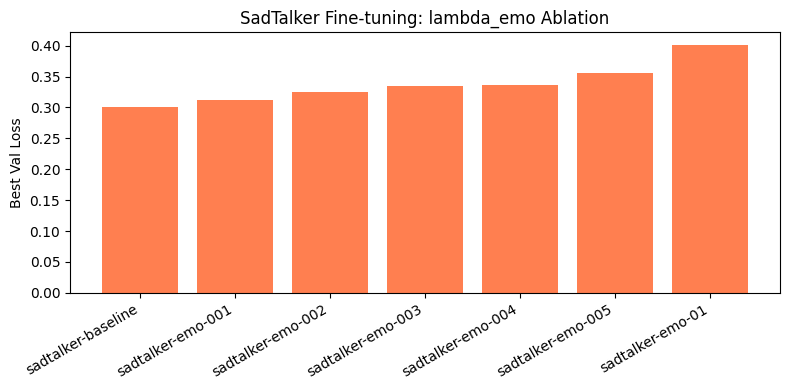

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(all_results)

# Fair cross-lambda selection:
# 1) keep models within 1% of the best reconstruction
# 2) among them select highest emotion accuracy
best_recon = df["best_recon"].min()
recon_tol = 0.01 * best_recon
df["within_recon_band"] = df["best_recon"] <= (best_recon + recon_tol)
df["selection_score"] = df["best_emo_accuracy"].where(df["within_recon_band"], -1.0)

df = df.sort_values(
    ["selection_score", "best_recon", "best_emo_accuracy", "best_val"],
    ascending=[False, True, False, True],
).reset_index(drop=True)

print(
    "Selection rule: maximize emotion accuracy among models within 1% "
    f"of best recon (best recon={best_recon:.4f})."
)
print(
    df[["name", "lambda_emo", "best_recon", "best_emo_accuracy", "best_val", "within_recon_band"]]
    .to_string(index=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df["name"], df["best_recon"], color="steelblue")
axes[0].set_ylabel("Best Val Recon (L1)")
axes[0].set_title("Reconstruction by Lambda")

axes[1].bar(df["name"], df["best_emo_accuracy"], color="darkorange")
axes[1].set_ylabel("Emotion Accuracy")
axes[1].set_title("Emotion Accuracy by Lambda")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")

plt.tight_layout()
plt.show()



In [9]:
best_name = df.iloc[0]["name"]
best_lambda = float(df.iloc[0]["lambda_emo"])

best_netG = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
best_emo_head = nn.Linear(64, len(EMOTIONS)).to(DEVICE)

ckpt = torch.load(OUT_DIR / best_name / "model.pth", map_location=DEVICE)
best_netG.load_state_dict(ckpt["netG"])
best_emo_head.load_state_dict(ckpt["emo_head"])

best_w_coeff = float(ckpt.get("w_coeff_exp", W_COEFF_EXP))
best_mode = ckpt.get("unfreeze_mode", "unknown")

metrics = evaluate(best_netG, best_emo_head, val_loader, best_lambda, best_w_coeff)

print(f"Loaded best model: {best_name} (lambda_emo={best_lambda})")
print(f"Unfreeze mode: {best_mode}, W_COEFF_EXP={best_w_coeff}")
print("\nBest model evaluation:")
print(f"  Avg coeff L1:       {metrics['recon']:.4f}")
print(f"  Emotion loss:       {metrics['emotion']:.4f}")
print(f"  Emotion accuracy:   {metrics['emo_accuracy']:.4f}")

del best_netG, best_emo_head
torch.cuda.empty_cache()


using safetensor as default


Loaded best model: sadtalker-baseline (lambda_emo=0.0)
Unfreeze mode: upper_audio, W_COEFF_EXP=2.0

Best model evaluation:
  Avg coeff L1:       0.1503
  Emotion loss:       0.0000
  Emotion accuracy:   0.2500


In [10]:
baseline_name = "sadtalker-baseline"
best_name = df.iloc[0]["name"]

def load_variant(name):
    lam = float(df[df["name"] == name].iloc[0]["lambda_emo"])
    netG = load_sadtalker_netg(SADTALKER_CKPT, DEVICE)
    emo_head = nn.Linear(64, len(EMOTIONS)).to(DEVICE)
    ckpt = torch.load(OUT_DIR / name / "model.pth", map_location=DEVICE)
    netG.load_state_dict(ckpt["netG"])
    emo_head.load_state_dict(ckpt["emo_head"])
    w_coeff = float(ckpt.get("w_coeff_exp", W_COEFF_EXP))
    return netG, emo_head, lam, w_coeff

baseline_netG, baseline_head, baseline_lambda, baseline_w = load_variant(baseline_name)
best_netG, best_head, best_lambda, best_w = load_variant(best_name)

print("Evaluating baseline...")
baseline_metrics = evaluate(baseline_netG, baseline_head, val_loader, baseline_lambda, baseline_w)
print("Evaluating best...")
best_metrics = evaluate(best_netG, best_head, val_loader, best_lambda, best_w)

cmp = pd.DataFrame({
    "metric": ["coeff L1", "emo_accuracy"],
    baseline_name: [baseline_metrics["recon"], baseline_metrics["emo_accuracy"]],
    best_name: [best_metrics["recon"], best_metrics["emo_accuracy"]],
})
cmp["delta"] = cmp[best_name] - cmp[baseline_name]
print("\n=== Baseline vs Best comparison ===")
print(cmp.to_string(index=False))

del baseline_netG, baseline_head, best_netG, best_head
torch.cuda.empty_cache()


using safetensor as default
using safetensor as default
Evaluating baseline...


Evaluating best...



=== Baseline vs Best comparison ===
      metric  sadtalker-baseline  delta
    coeff L1            0.150257    0.0
emo_accuracy            0.250000    0.0
